#  Customer Segmentation and Profiling

In [ ]:
import pandas as pd
df = pd.read_csv('CleanedData.csv')
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Few times a month,others,Multiple pages,4,Yes,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Rarely,categories,Multiple pages,1,Maybe,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Rarely,Keyword,First page,2,Yes,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,others,Multiple pages,2,Maybe,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Few times a month,Filter,First page,5,No,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [ ]:
df['Purchase_Frequency'].unique()

array(['Once a week', 'Once a month', 'Multiple times a week',
       'Few times a month', 'Less than once a month'], dtype=object)

In [ ]:
# Segmenting the Customers based on Purchase Frequency
freq_level = {
    'Multiple times a week' : 5,
    'Once a week' : 4,
    'Few times a month' : 3,
    'Once a month' : 2,
    'Less than once a month' : 1
}

In [ ]:
# Mapping the frequency levels with the purchase frequency
df['Purchase_Frequency_Level'] = df['Purchase_Frequency'].map(freq_level)

In [ ]:
# Satisfaction Levels of the Customers
df['Shopping_Satisfaction'].unique()

array([3, 2, 5, 1, 4])

In [ ]:
df['Cart_Completion_Frequency'].unique()

array(['Rarely', 'Often', 'Never', 'Sometimes', 'Always'], dtype=object)

In [ ]:
# Mapping the Cart Completion Frequency
cart_completion_freq = {
    'Never' : 1,
    'Rarely' : 2,
    'Sometimes' : 3,
    'Often' : 4,
    'Always' : 5
}

In [ ]:
df['Cart_Completion_Frequency_Level'] = df['Cart_Completion_Frequency'].map(cart_completion_freq)

### Frequent Buyers : High Purchase Frequency and High Satisfaction

In [ ]:
# 128 Customers are Frequent Buyers
df_freq_buyers = df[(df['Purchase_Frequency_Level'] >= 4) & (df['Shopping_Satisfaction'] >= 4)]
Profile1 = df_freq_buyers[['age', 'Gender',
       'Purchase_Categories', 'Product_Search_Method',
       'Cart_Abandonment_Factors',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Purchase_Frequency_Level',
       'Cart_Completion_Frequency_Level']]

In [ ]:
Profile1.head()

,age,Gender,Purchase_Categories,Product_Search_Method,Cart_Abandonment_Factors,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Purchase_Frequency_Level,Cart_Completion_Frequency_Level
5,33,Female,Groceries and Gourmet Food;Beauty and Personal...,categories,others,5,Sometimes,4,4,5,4
12,7,Others,others,Unknown,Changed my mind or no longer need the item,5,Yes,5,5,5,4
13,48,Male,Groceries and Gourmet Food;Beauty and Personal...,others,Found a better price elsewhere,3,Sometimes,5,5,5,4
17,60,Others,Clothing and Fashion;Home and Kitchen;others,others,Found a better price elsewhere,4,Sometimes,3,4,4,3
23,44,Female,Beauty and Personal Care;Clothing and Fashion;...,Keyword,High shipping costs,3,Yes,2,4,4,1


### Occasional Shoppers: Medium Frequency and Moderate satisfaction.

In [ ]:
df_occasional_shoppers = df[(df['Purchase_Frequency_Level'] >= 2) & (df['Purchase_Frequency_Level'] < 4) & (df['Shopping_Satisfaction'] >= 2) & (df['Shopping_Satisfaction'] < 4)]
Profile2 = df_occasional_shoppers[['age', 'Gender', 'Product_Search_Method',
       'Cart_Abandonment_Factors', 'Personalized_Recommendation_Frequency',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Purchase_Frequency_Level',
       'Cart_Completion_Frequency_Level']]

In [ ]:
Profile2.shape

(139, 10)

In [ ]:
Profile2.head()

,age,Gender,Product_Search_Method,Cart_Abandonment_Factors,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Purchase_Frequency_Level,Cart_Completion_Frequency_Level
1,48,Female,categories,Changed my mind or no longer need the item,1,No,5,2,2,4
6,10,Male,Unknown,Found a better price elsewhere,1,Yes,3,2,2,2
8,8,Female,Filter,High shipping costs,5,Sometimes,1,2,2,2
11,15,Others,Unknown,Found a better price elsewhere,4,Yes,5,3,2,4
28,20,Female,Unknown,High shipping costs,5,Sometimes,5,3,3,4


### At-Risk Customers: Low Satisfaction and Low Cart Completion

In [ ]:
# Customers are At Risk
df_at_risk = df[(df['Shopping_Satisfaction'] < 2) & (df['Cart_Completion_Frequency_Level'] < 2)]

In [ ]:
Profile3 = df_at_risk[['age', 'Gender', 'Product_Search_Method',
       'Cart_Abandonment_Factors', 'Personalized_Recommendation_Frequency',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Purchase_Frequency_Level',
       'Cart_Completion_Frequency_Level']]
Profile3.shape

(31, 10)

In [ ]:
Profile3.head()

,age,Gender,Product_Search_Method,Cart_Abandonment_Factors,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Purchase_Frequency_Level,Cart_Completion_Frequency_Level
4,51,Female,Filter,Changed my mind or no longer need the item,1,Yes,3,1,2,1
31,27,Male,Unknown,others,1,No,3,1,4,1
44,9,Others,Keyword,Changed my mind or no longer need the item,2,No,1,1,2,1
50,37,Female,Keyword,Changed my mind or no longer need the item,5,Sometimes,1,1,5,1
71,40,Female,Keyword,Found a better price elsewhere,5,Yes,5,1,2,1


In [ ]:
# Customer Segmentation
def segment(row):
    if (row['Purchase_Frequency_Level'] >= 4) & (row['Shopping_Satisfaction'] >= 4):
        return 'Frequent Shopper'
    elif (row['Cart_Completion_Frequency_Level'] < 2) & (row['Shopping_Satisfaction'] < 2):
        return 'At Risk'
    else:
        return 'Occasional Shopper'
df['Customer_Segmentation'] = df.apply(segment, axis=1)


In [ ]:
df['Customer_Segmentation'].tail()

,Customer_Segmentation
795,Occasional Shopper
796,Frequent Shopper
797,Frequent Shopper
798,Occasional Shopper
799,Occasional Shopper


In [ ]:
df['Customer_Segmentation'].value_counts(normalize=True).round(4)*100

,proportion
Customer_Segmentation,
Occasional Shopper,80.12
Frequent Shopper,16.00
At Risk,3.88


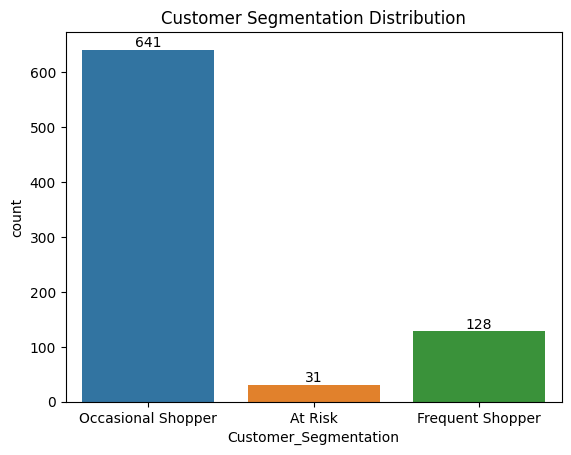

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.countplot(x='Customer_Segmentation', data=df, hue='Customer_Segmentation')
for p in ax.containers:
    ax.bar_label(p)
plt.title('Customer Segmentation Distribution')
plt.show()

In [ ]:
# 16% of the customers are loyal and highly satisfied
# 80% of the customers are occasional buyers which shows huge potential
# to convert 5% to 10% of these customers into frequent buyers by
# loyalty programs, personalized recommendations and discount offers


## Analyzing demographic or behavioral differences across these Customer Segments.

In [ ]:
# Comparitively Younger Customers are at risk category than other two
df.groupby('Customer_Segmentation')['age'].mean()

,age
Customer_Segmentation,
At Risk,28.000000
Frequent Shopper,35.984375
Occasional Shopper,36.457098


In [ ]:
# Male percentage is high in frequent buyers
# Male and Female percentage is identical in at risk customers
pd.crosstab(
    df['Customer_Segmentation'],
    df['Gender'], normalize='index'
).round(3)*100


Gender,Female,Male,Others,Prefer not to say
Customer_Segmentation,,,,
At Risk,25.8,25.8,35.5,12.9
Frequent Shopper,21.1,28.1,27.3,23.4
Occasional Shopper,25.9,26.4,22.8,25.0


In [ ]:
# Most percentage of frequent shoppers buy through Filter and other methods
# While occasional buyers majorly shop through keyword search and other methods
pd.crosstab(
    df['Customer_Segmentation'],
    df['Product_Search_Method'], normalize='index'
).round(3)*100

Product_Search_Method,Filter,Keyword,Unknown,categories,others
Customer_Segmentation,,,,,
At Risk,22.6,22.6,16.1,19.4,19.4
Frequent Shopper,23.4,18.0,18.8,15.6,24.2
Occasional Shopper,17.6,20.7,18.7,20.3,22.6


## K-Means Clustering for behavioral grouping based on survey responses

In [ ]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction', 'Purchase_Frequency_Level',
       'Cart_Completion_Frequency_Level', 'Customer_Segmentation'],
      dtype='object')

In [ ]:
# Input Data : Most Important Features to segment customers
df_input = df[['Shopping_Satisfaction', 'Purchase_Frequency_Level']]

In [ ]:
df_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Shopping_Satisfaction     800 non-null    int64
 1   Purchase_Frequency_Level  800 non-null    int64
dtypes: int64(2)
memory usage: 12.6 KB


In [ ]:
# Standardizing the input data (0 to 1) for correct distance calculations in Kmeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
std_data = scaler.fit_transform(df_input)

In [ ]:
# WCSS calculation to find the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(std_data)
    wcss.append(kmeans.inertia_)

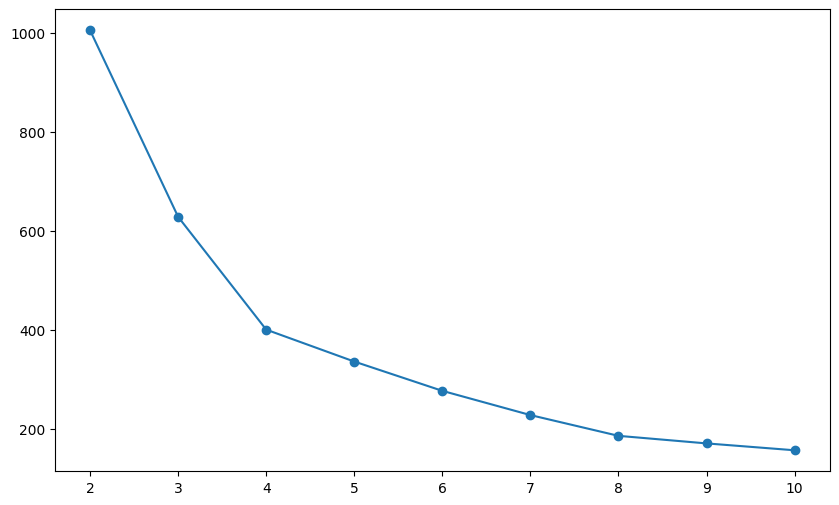

In [ ]:
# Elbow Method - 4 Clusters
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.show()

In [ ]:
# Silhouette Score : Highest for 4 Clusters
from sklearn.metrics import silhouette_score
for i in range(2,6):
  km = KMeans(n_clusters=i, random_state=42)
  km.fit(std_data)
  labels = km.labels_
  score = silhouette_score(std_data, labels)
  print(f"Number of clusters: {i}, Silhouette score: {score}")

Number of clusters: 2, Silhouette score: 0.36659482065592885
Number of clusters: 3, Silhouette score: 0.40311784347237845
Number of clusters: 4, Silhouette score: 0.43988478226658034
Number of clusters: 5, Silhouette score: 0.41485361263851445


In [ ]:
# KMeans Clustering with 4 Clusters
group = KMeans(n_clusters=4)
group.fit(std_data)

KMeans(n_clusters=4)

In [ ]:
df['Cluster'] = group.labels_

In [ ]:
centers = group.cluster_centers_

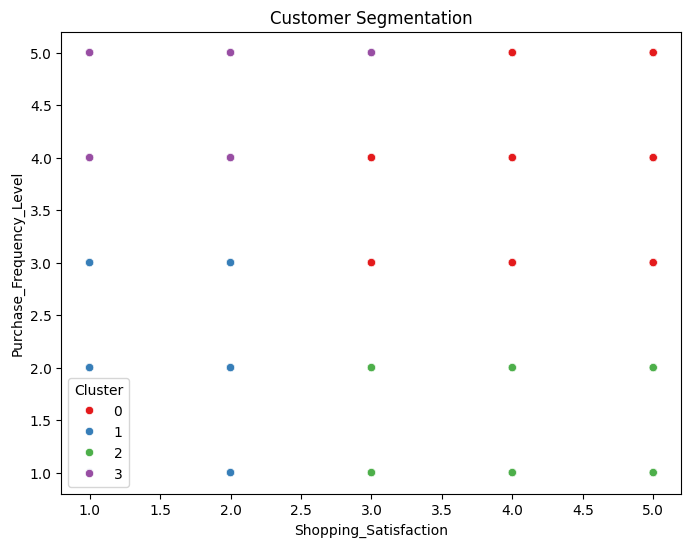

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Shopping_Satisfaction', y='Purchase_Frequency_Level', hue='Cluster', data=df,
                palette='Set1')
plt.title('Customer Segmentation')
plt.show()

In [ ]:
cluster_profile = df.groupby('Cluster')[
    ['Shopping_Satisfaction', 'Purchase_Frequency_Level']
].mean().round(2)

cluster_profile

,Shopping_Satisfaction,Purchase_Frequency_Level
Cluster,,
0,4.13,3.89
1,1.51,2.08
2,3.95,1.48
3,1.83,4.63


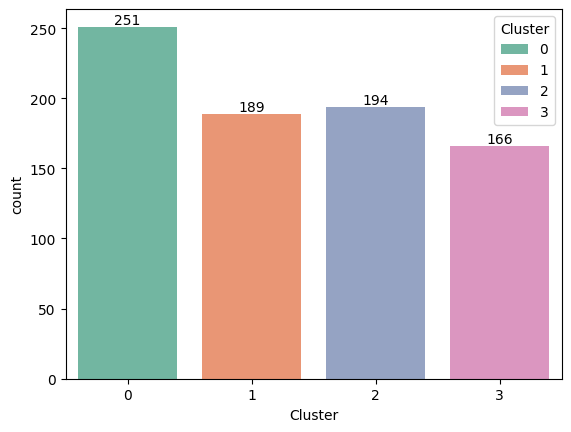

In [ ]:
ax = sns.countplot(x='Cluster', data=df, hue='Cluster', palette='Set2')
for p in ax.containers:
    ax.bar_label(p)
plt.show()

In [ ]:
# Recommended Strategy -
# 1. Loyal / Frequent Buyers (Cluster 0) -	Retain & increase lifetime value
# 2. Satisfied Occasional Shoppers (Cluster 2) - Increase purchase frequency
# 3. Frequent but Dissatisfied (Cluster 3) - Fix pain points & prevent churn
# 4. At-Risk / Disengaged	(Cluster 1) -	Re-engage or recover

In [ ]:
df.to_csv('clustered_data.csv', index=False)